Step 1: Library Setup

In [1]:
#  Basic Python libraries
import pandas as pd
import numpy as np
import os
from datetime import datetime, timedelta

# 📊 Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# 🧠 Machine Learning
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM, SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

#  NLP and text preprocessing
import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# ⚙️ Joblib for saving models
import joblib

#  Download NLTK data
nltk.download("punkt")
nltk.download("stopwords")


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\afsar\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\afsar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

Step 2: Preprocessing (cleaning, timestamp, category, adding missing identifiers)

In [3]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# --- File Paths ---
raw_log_path = "Windows Event Logs.csv"  # The raw event log file
category_map_path = "Windows_Security_Audit_Events.csv"  # Event ID with category to merge
save_path = "Windows_Events_Log_With_Synthetic_Users.csv"  # Output file after the preprocessing

# --- keeping necessary columns only ---
columns_to_keep = [
    "Event ID", "Security Identifier", "Created Date/Time - UTC+00:00 (dd/MM/yyyy)",
    "Event Record ID", "Event Description Summary", "Level",
    "Provider Name", "Task Category", "Location"
]

df = pd.read_csv(raw_log_path, usecols=columns_to_keep, dtype=str, low_memory=False)
print(f" Loaded {len(df)} rows from raw logs.")

# --- Assign random dates to normalize datetime format ---
start_date = datetime(2019, 1, 1)
end_date = datetime(2024, 1, 1)
np.random.seed(42)

random_dates = [
    start_date + timedelta(days=np.random.randint(0, (end_date - start_date).days))
    for _ in range(len(df))
]

df["Created Date/Time - UTC+00:00 (dd/MM/yyyy)"] = df["Created Date/Time - UTC+00:00 (dd/MM/yyyy)"].astype(str)
df["Created Date/Time - UTC+00:00 (dd/MM/yyyy)"] = [
    random_dates[i].strftime("%d-%m-%Y") + " " + df.iloc[i]['Created Date/Time - UTC+00:00 (dd/MM/yyyy)']
    for i in range(len(df))
]

df["Created Date/Time - UTC+00:00 (dd/MM/yyyy)"] = pd.to_datetime(
    df["Created Date/Time - UTC+00:00 (dd/MM/yyyy)"],
    format="%d-%m-%Y %S:%M.%H",
    errors='coerce'
)
df["timestamp"] = df["Created Date/Time - UTC+00:00 (dd/MM/yyyy)"]

# ---  Merge with Event Category Mapping ---
df_cat = pd.read_csv(category_map_path)
df["Event ID"] = df["Event ID"].astype(int)
df_cat["Event ID"] = df_cat["Event ID"].astype(int)

df = df.merge(df_cat[["Event ID", "Category"]], on="Event ID", how="left")
df["Category"] = df["Category"].fillna("Other")

# --- Fill missing Security Identifier with synthetic users (only where needed) ---
df["Security Identifier"] = df["Security Identifier"].replace(
    ["", " ", "nan", "NaN", "NONE", "None"], np.nan
)

if df["Security Identifier"].isna().sum() > 0:
    print(" Missing Security Identifiers found. Filling with synthetic users...")
    user_map = {
        "Logon/Logoff": ["UserA", "UserB", "Admin"],
        "Privilege Use": ["Admin", "UserA"],
        "Account Management": ["Admin", "ServiceAccount1"],
        "System": ["SYSTEM", "ServiceAccount2"],
        "Policy Change": ["Admin"],
        "Detailed Tracking": ["ServiceAccount2", "SYSTEM", "UserC"],
        "Object Access": ["Admin", "UserA", "ServiceAccount1"],
        "Other": ["UserC", "UserD", "Guest"]
    }
    for category, users in user_map.items():
        mask = (df["Security Identifier"].isna()) & (df["Category"] == category)
        df.loc[mask, "Security Identifier"] = np.random.choice(users, size=mask.sum())
    print(" Synthetic users assigned.")
else:
    print(" No missing Security Identifiers.")

# --- Save final cleaned dataset to current notebook directory ---
df.to_csv(save_path, index=False)
print(f" Cleaned dataset saved to: {save_path}")


 Loaded 179288 rows from raw logs.
 Missing Security Identifiers found. Filling with synthetic users...
 Synthetic users assigned.
 Cleaned dataset saved to: Windows_Events_Log_With_Synthetic_Users.csv


Step 3 Feature Engineering (Producing features for anomaly detection)

In [5]:
# Feature Engineering

# Load cleaned dataset from previous step
df = pd.read_csv("Windows_Events_Log_With_Synthetic_Users.csv", low_memory=False)

# Convert timestamp for session analysis
df["timestamp"] = pd.to_datetime(df["Created Date/Time - UTC+00:00 (dd/MM/yyyy)"], errors="coerce")

# ---------------- LOGIN FREQUENCY ----------------
logon_df = df[df["Category"].str.contains("Logon/Logoff", case=False, na=False)]
login_freq = logon_df.groupby("Security Identifier").size().reset_index(name="login_frequency")
df = df.merge(login_freq, on="Security Identifier", how="left")
df["login_frequency"] = df["login_frequency"].fillna(0).astype(int)

# ---------------- FAILED LOGIN ATTEMPTS ----------------
failed_df = df[df["Event ID"].astype(str) == "4625"]
failed_login_freq = failed_df.groupby("Security Identifier").size().reset_index(name="failed_login_attempts")
df = df.merge(failed_login_freq, on="Security Identifier", how="left")
df["failed_login_attempts"] = df["failed_login_attempts"].fillna(0).astype(int)

# ---------------- FILE ACCESS COUNT ----------------
file_access_df = df[df["Category"] == "Object Access"]
file_access_freq = file_access_df.groupby("Security Identifier").size().reset_index(name="file_access_count")
df = df.merge(file_access_freq, on="Security Identifier", how="left")
df["file_access_count"] = df["file_access_count"].fillna(0).astype(int)

# ---------------- SESSION DURATION ----------------
logons = df[df["Event ID"].astype(str) == "4624"].copy()
logoffs = df[df["Event ID"].astype(str) == "4634"].copy()

logons = logons.dropna(subset=["timestamp"])
logoffs = logoffs.dropna(subset=["timestamp"])

if not logoffs.empty and not logons.empty:
    logons.rename(columns={"timestamp": "timestamp_logon"}, inplace=True)
    logoffs.rename(columns={"timestamp": "timestamp_logoff"}, inplace=True)
    logons.sort_values(by=["timestamp_logon", "Security Identifier"], inplace=True)
    logoffs.sort_values(by=["timestamp_logoff", "Security Identifier"], inplace=True)

    sessions = pd.merge_asof(
        logons, logoffs,
        by="Security Identifier",
        left_on="timestamp_logon",
        right_on="timestamp_logoff",
        direction="forward"
    )

    sessions["session_duration_min"] = (
        sessions["timestamp_logoff"] - sessions["timestamp_logon"]
    ).dt.total_seconds() / 60

    sessions = sessions[sessions["session_duration_min"] >= 0]

    avg_session = sessions.groupby("Security Identifier")["session_duration_min"] \
                          .mean().reset_index(name="avg_session_duration")

    df = df.merge(avg_session, on="Security Identifier", how="left")
else:
    df["avg_session_duration"] = None

# ---------------- TOTAL EVENT COUNT ----------------
event_volume = df.groupby("Security Identifier").size().reset_index(name="total_event_count")
df = df.merge(event_volume, on="Security Identifier", how="left")

# ---------------- APPLICATION ACTIVITY ----------------
keywords = ["application", "install", "app", "applocker", "process", "executable", ".exe"]
app_df = df[df["Event Description Summary"].str.lower().fillna("").str.contains('|'.join(keywords))]
app_activity = app_df.groupby("Security Identifier").size().reset_index(name="application_activity_count")
df = df.merge(app_activity, on="Security Identifier", how="left")
df["application_activity_count"] = df["application_activity_count"].fillna(0).astype(int)

# ---------------- Save the featured enhanced dataset ----------------
df.to_csv("Windows_Event_Log_Feature_Enhanced.csv", index=False)
print(" Feature-enhanced dataset saved to: Windows_Event_Log_Feature_Enhanced.csv")


 Feature-enhanced dataset saved to: Windows_Event_Log_Feature_Enhanced.csv


Pull out the user vehaviour Summary form the "Feature Enhanced dataset"

In [7]:
# Group by each user and compute their average behavior
user_summary = df.groupby("Security Identifier")[[
    "login_frequency",
    "failed_login_attempts",
    "file_access_count",
    "application_activity_count",
    "avg_session_duration",
    "total_event_count"
]].mean().reset_index()

# View the summary
import pandas as pd
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import matplotlib.pyplot as plt
import seaborn as sns

# Save summary for reference
user_summary.to_csv("User_Behavior_Summary.csv", index=False)

# Display the top users sorted by login frequency
user_summary.sort_values("login_frequency", ascending=False).head(10)


,Security Identifier,login_frequency,failed_login_attempts,file_access_count,application_activity_count,avg_session_duration,total_event_count
18,UserB,1412.0,11.0,0.0,0.0,83972.687913,1412.0
0,Admin,1388.0,8.0,8.0,0.0,86451.444327,8250.0
17,UserA,1368.0,12.0,7.0,0.0,67984.153115,3240.0
11,S-1-5-96-0-0,0.0,0.0,0.0,0.0,NaN,65.0
19,UserC,0.0,0.0,0.0,568.0,NaN,1910.0
16,ServiceAccount2,0.0,0.0,0.0,129.0,NaN,438.0
15,ServiceAccount1,0.0,0.0,7.0,0.0,NaN,1731.0
14,SYSTEM,0.0,0.0,0.0,127.0,NaN,411.0
13,S-1-5-96-0-2,0.0,0.0,0.0,0.0,NaN,9.0
12,S-1-5-96-0-1,0.0,0.0,0.0,0.0,NaN,60.0


Flagging Unusual Cases for later use

In [9]:
# Example: Users with extremely high login frequency (top 10%)
high_login_threshold = user_summary["login_frequency"].quantile(0.90)
high_login_users = user_summary[user_summary["login_frequency"] > high_login_threshold]

# Example: Users with very low or no activity
inactive_users = user_summary[
    (user_summary["login_frequency"] == 0) &
    (user_summary["file_access_count"] == 0) &
    (user_summary["application_activity_count"] == 0)
]

# Show results
print(" Users with unusually high login frequency:")
display(high_login_users)

print(" Users with no recorded activity:")
display(inactive_users)


 Users with unusually high login frequency:


,Security Identifier,login_frequency,failed_login_attempts,file_access_count,application_activity_count,avg_session_duration,total_event_count
0,Admin,1388.0,8.0,8.0,0.0,86451.444327,8250.0
18,UserB,1412.0,11.0,0.0,0.0,83972.687913,1412.0


 Users with no recorded activity:


,Security Identifier,login_frequency,failed_login_attempts,file_access_count,application_activity_count,avg_session_duration,total_event_count
11,S-1-5-96-0-0,0.0,0.0,0.0,0.0,NaN,65.0
12,S-1-5-96-0-1,0.0,0.0,0.0,0.0,NaN,60.0
13,S-1-5-96-0-2,0.0,0.0,0.0,0.0,NaN,9.0


Step 4: Modeling and Anomaly detection

Unsupervised Models

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM

# Step 1: Prepare user-level data
user_df = df[[
    "Security Identifier",
    "login_frequency",
    "failed_login_attempts",
    "file_access_count",
    "application_activity_count",
    "avg_session_duration",
    "total_event_count"
]].drop_duplicates().reset_index(drop=True)

# Step 2: Handle missing session duration (if any)
user_df["avg_session_duration"] = user_df["avg_session_duration"].fillna(0)

# Step 3: Scale features (important for distance-based models)
scaler = StandardScaler()
X = user_df.drop("Security Identifier", axis=1)
X_scaled = scaler.fit_transform(X)

# Step 4: Apply models
# Isolation Forest
iso_model = IsolationForest(n_estimators=100, contamination=0.1, random_state=42)
user_df["iso_label"] = iso_model.fit_predict(X_scaled)

# LOF
lof_model = LocalOutlierFactor(n_neighbors=5, contamination=0.1)
user_df["lof_label"] = lof_model.fit_predict(X_scaled)

# One-Class SVM
ocsvm_model = OneClassSVM(kernel="rbf", gamma="scale", nu=0.1)
user_df["svm_label"] = ocsvm_model.fit_predict(X_scaled)

# Step 5: Map results to readable labels
label_map = {1: "Normal", -1: "Anomalous"}
user_df["iso_label"] = user_df["iso_label"].map(label_map)
user_df["lof_label"] = user_df["lof_label"].map(label_map)
user_df["svm_label"] = user_df["svm_label"].map(label_map)

# View results
user_df[["Security Identifier", "iso_label", "lof_label", "svm_label"]].head(10)


,Security Identifier,iso_label,lof_label,svm_label
0,LocalService,Normal,Normal,Anomalous
1,UserD,Normal,Normal,Normal
2,UserC,Normal,Normal,Anomalous
3,Guest,Normal,Normal,Normal
4,S-1-5-21-1418642363-203697023-882285408-1001,Normal,Normal,Normal
5,LocalSystem,Anomalous,Normal,Normal
6,NetworkService,Normal,Normal,Normal
7,S-1-5-21-1418642363-203697023-882285408-1000,Normal,Normal,Normal
8,Admin,Normal,Normal,Normal
9,UserB,Anomalous,Anomalous,Anomalous


In [ ]:
Supervised Models

First Step Of Supervised Model: Preprocess Text for Supervised Learning

In [17]:
import pandas as pd
import re
from sklearn.preprocessing import LabelEncoder
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk

# Download NLTK resources (only once per environment)
nltk.download("punkt")
nltk.download("stopwords")

# Load your enhanced dataset
df = pd.read_csv("Windows_Event_Log_Feature_Enhanced.csv")

# Drop rows where 'Level' or 'Event Description Summary' is missing
df = df.dropna(subset=["Level", "Event Description Summary"]).copy()

#  Text cleaning function
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    tokens = text.split()  # simpler and doesn't need NLTK tokenizer
    tokens = [t for t in tokens if t not in stopwords.words("english")]
    return " ".join(tokens)

#  Apply cleaning to event summaries
df["processed_text"] = df["Event Description Summary"].apply(preprocess_text)

#  Encode the 'Level' column into numeric labels
label_encoder = LabelEncoder()
df["level_encoded"] = label_encoder.fit_transform(df["Level"])

#  Check processed text and label encoding
df[["processed_text", "Level", "level_encoded"]].head(10)


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\afsar\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\afsar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,processed_text,Level,level_encoded
0,diagnostic module detected problem,Information,2
1,diagnostic module started troubleshooting scen...,Information,2
2,diagnostic module detected problem,Information,2
63,account successfully logged,Information,2
64,account successfully logged,Information,2
65,special privileges assigned new logon,Information,2
66,account successfully logged,Information,2
67,special privileges assigned new logon,Information,2
68,logon attempted using explicit credentials,Information,2
69,account successfully logged,Information,2


Second Step: Train two supervised models:

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, accuracy_score, precision_score, f1_score
from sklearn.preprocessing import LabelEncoder

#  Vectorize text using TF-IDF
vectorizer = TfidfVectorizer(max_features=1000)
X = vectorizer.fit_transform(df["processed_text"])

#  Target variable (encoded event level)
y = df["level_encoded"]

#  Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Random Forest Classifier ---
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Classification Report:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, average="weighted"))
print("F1 Score:", f1_score(y_test, y_pred_rf, average="weighted"))
print("\nDetailed Report:\n", classification_report(y_test, y_pred_rf))

# --- Support Vector Machine Classifier ---
svm_model = SVC(kernel="linear", random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

print("\n SVM Classification Report:")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm, average="weighted"))
print("F1 Score:", f1_score(y_test, y_pred_svm, average="weighted"))
print("\nDetailed Report:\n", classification_report(y_test, y_pred_svm))


Random Forest Classification Report:
Accuracy: 0.9993478260869565
Precision: 0.9993861721050944
F1 Score: 0.9993560635579419

Detailed Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00       155
           1       0.90      1.00      0.95        19
           2       1.00      1.00      1.00      4354
           3       0.99      0.97      0.98        72

    accuracy                           1.00      4600
   macro avg       0.97      0.99      0.98      4600
weighted avg       1.00      1.00      1.00      4600


 SVM Classification Report:
Accuracy: 0.9993478260869565
Precision: 0.9993861721050944
F1 Score: 0.9993560635579419

Detailed Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00       155
           1       0.90      1.00      0.95        19
           2       1.00      1.00      1.00      4354
           3       0.99      0.97      0.98        72

    accuracy 

Save the Model for later Use

In [37]:
import joblib
import os

# Create a folder for the models (if not exists)
os.makedirs("models", exist_ok=True)

# --- Save unsupervised models 
joblib.dump(iso_model, "models/isolation_forest.pkl")  # Isolation Forest
joblib.dump(lof_model, "models/lof_model.pkl")           # Local Outlier Factor
joblib.dump(ocsvm_model, "models/ocsvm_model.pkl")       # One-Class SVM

# --- Save supervised components
joblib.dump(rf_model, "models/rf_model.pkl")       # Random Forest
joblib.dump(svm_model, "models/svm_model.pkl")            # SVM
joblib.dump(vectorizer, "models/tfidf_vectorizer.pkl")
joblib.dump(label_encoder, "models/level_label_encoder.pkl")

# --- Save scaler
joblib.dump(scaler, "models/scaler.pkl")

# # Save models
# joblib.dump(rf_model, "notebook_models/rf_model.pkl")
# joblib.dump(svm_model, "notebook_models/svm_model.pkl")
# joblib.dump(vectorizer, "notebook_models/tfidf_vectorizer.pkl")
# joblib.dump(label_encoder, "notebook_models/label_encoder.pkl")


print(" All models and vectorizers saved to 'notebook_models/' folder.")


 All models and vectorizers saved to 'notebook_models/' folder.


Visualize the Model Performance

Confusion Matrices:

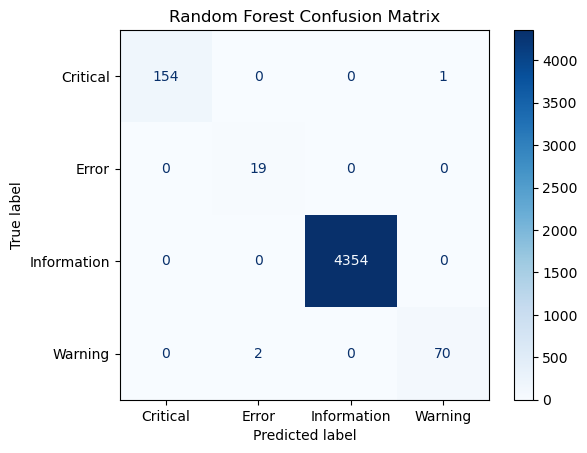

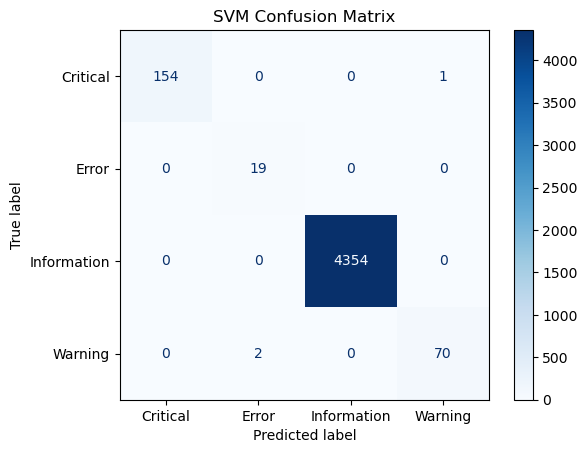

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Plot confusion matrix for Random Forest
ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test, display_labels=label_encoder.classes_, cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.show()

# Plot confusion matrix for SVM
ConfusionMatrixDisplay.from_estimator(svm_model, X_test, y_test, display_labels=label_encoder.classes_, cmap="Blues")
plt.title("SVM Confusion Matrix")
plt.show()


Bar Chart of Metrics

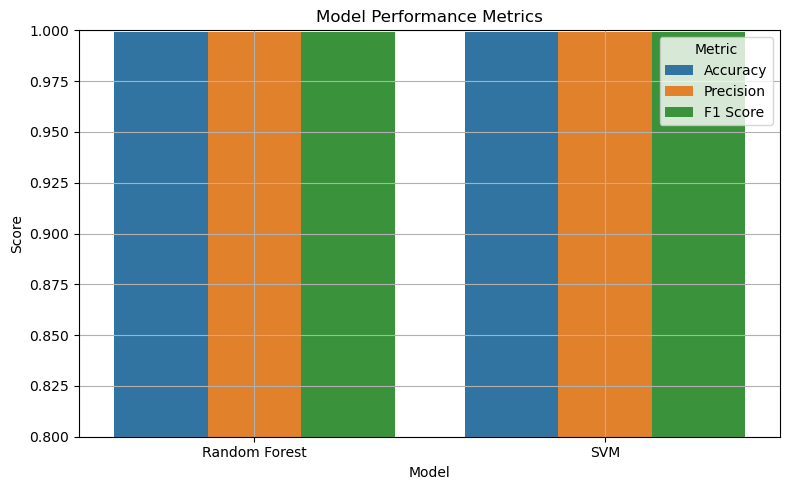

In [25]:
from sklearn.metrics import accuracy_score, precision_score, f1_score
import pandas as pd
import seaborn as sns

# Predictions
rf_pred = rf_model.predict(X_test)
svm_pred = svm_model.predict(X_test)

# Scores
scores = pd.DataFrame({
    "Model": ["Random Forest", "SVM"],
    "Accuracy": [accuracy_score(y_test, rf_pred), accuracy_score(y_test, svm_pred)],
    "Precision": [precision_score(y_test, rf_pred, average="weighted"), precision_score(y_test, svm_pred, average="weighted")],
    "F1 Score": [f1_score(y_test, rf_pred, average="weighted"), f1_score(y_test, svm_pred, average="weighted")]
})

# Melt for seaborn
scores_melted = scores.melt(id_vars="Model", var_name="Metric", value_name="Score")

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(data=scores_melted, x="Model", y="Score", hue="Metric")
plt.title("Model Performance Metrics")
plt.ylim(0.8, 1.0)
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
Anomaly Detected by Unsupervised Models

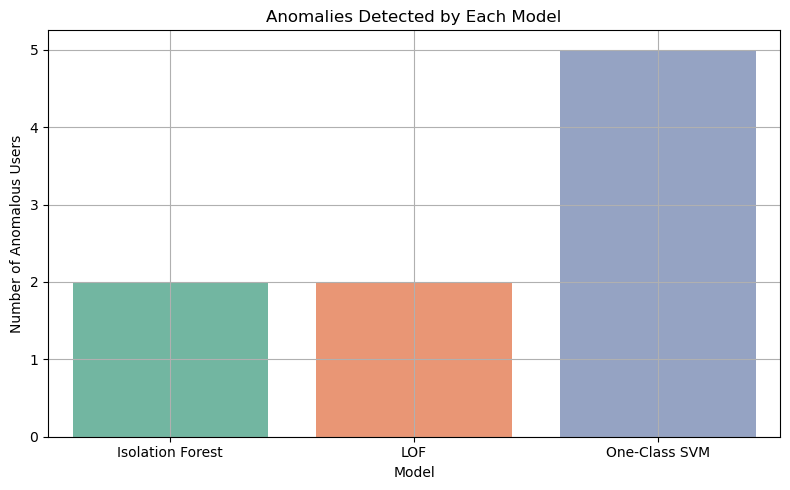

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count anomalies per model
anomaly_counts = {
    "Isolation Forest": sum(user_df["iso_label"] == "Anomalous"),
    "LOF": sum(user_df["lof_label"] == "Anomalous"),
    "One-Class SVM": sum(user_df["svm_label"] == "Anomalous")
}

plt.figure(figsize=(8,5))
sns.barplot(x=list(anomaly_counts.keys()), y=list(anomaly_counts.values()), palette="Set2")
plt.title("Anomalies Detected by Each Model")
plt.ylabel("Number of Anomalous Users")
plt.xlabel("Model")
plt.grid(True)
plt.tight_layout()
plt.show()


Anomaly detection by supervised models

In [45]:
# Preprocess event text (same as during training)
df["processed_text"] = df["Event Description Summary"].astype(str).apply(preprocess_text)

# Vectorize using your saved or previously used TF-IDF vectorizer
X_all = vectorizer.transform(df["processed_text"])
y_all = df["Level"]  # or whatever column contains the original log level


In [55]:
# Predict class indices
rf_preds = rf_model.predict(X_all)
svm_preds = svm_model.predict(X_all)

# Decode to label names (e.g., Information, Error, Warning, Critical)
rf_labels = label_encoder.inverse_transform(rf_preds)
svm_labels = label_encoder.inverse_transform(svm_preds)

# Define anomalous levels
anomaly_levels = ["Error", "Critical"]

# Count how many of each model's predictions are anomalous
rf_anomalies = sum(label in anomaly_levels for label in rf_labels)
svm_anomalies = sum(label in anomaly_levels for label in svm_labels)


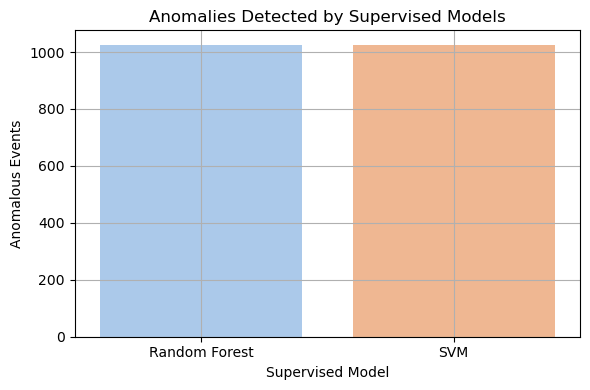

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.barplot(
    x=["Random Forest", "SVM"],
    y=[rf_anomalies, svm_anomalies],
    palette="pastel"
)
plt.title("Anomalies Detected by Supervised Models")
plt.ylabel("Anomalous Events")
plt.xlabel("Supervised Model")
plt.grid(True)
plt.tight_layout()
plt.show()


User anomaly detection heatmap

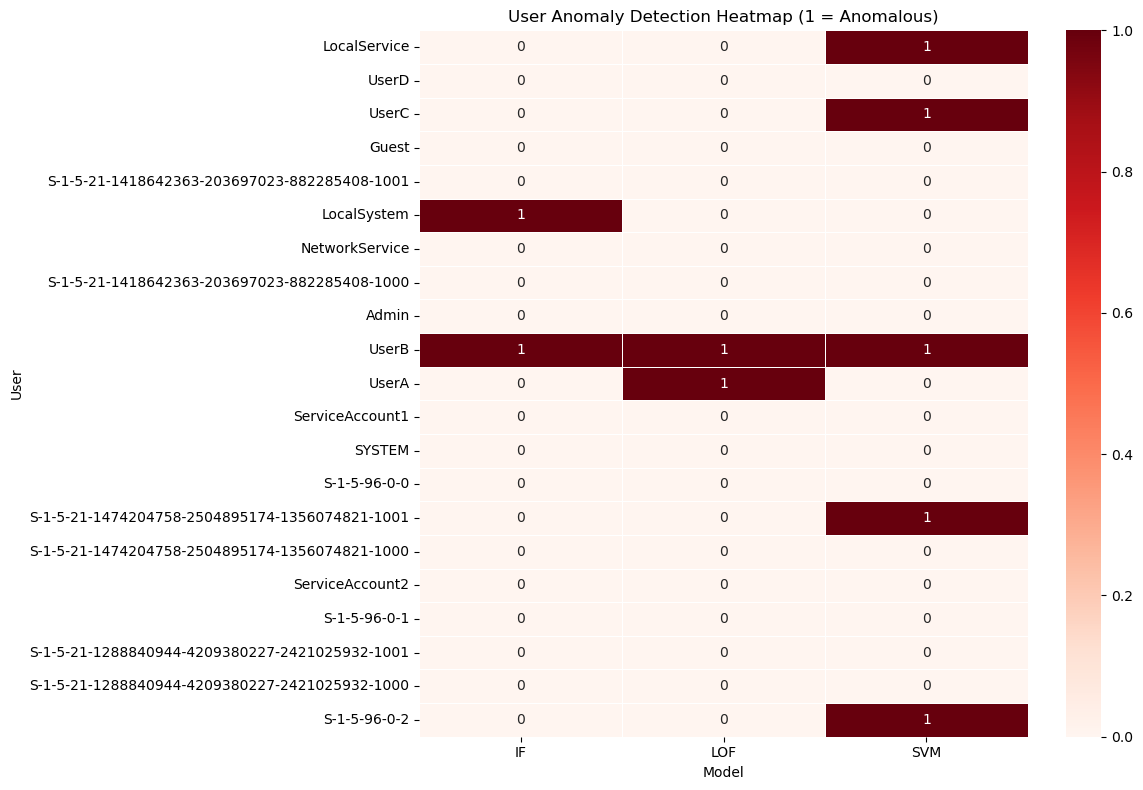

In [61]:
# Add binary flags
user_df["IF"] = user_df["iso_label"].map({"Normal": 0, "Anomalous": 1})
user_df["LOF"] = user_df["lof_label"].map({"Normal": 0, "Anomalous": 1})
user_df["SVM"] = user_df["svm_label"].map({"Normal": 0, "Anomalous": 1})

heatmap_data = user_df.set_index("Security Identifier")[["IF", "LOF", "SVM"]]

plt.figure(figsize=(12,8))
sns.heatmap(heatmap_data, cmap="Reds", annot=True, cbar=True, linewidths=0.5)
plt.title("User Anomaly Detection Heatmap (1 = Anomalous)")
plt.xlabel("Model")
plt.ylabel("User")
plt.tight_layout()
plt.show()


Top 10 users by login Frequency

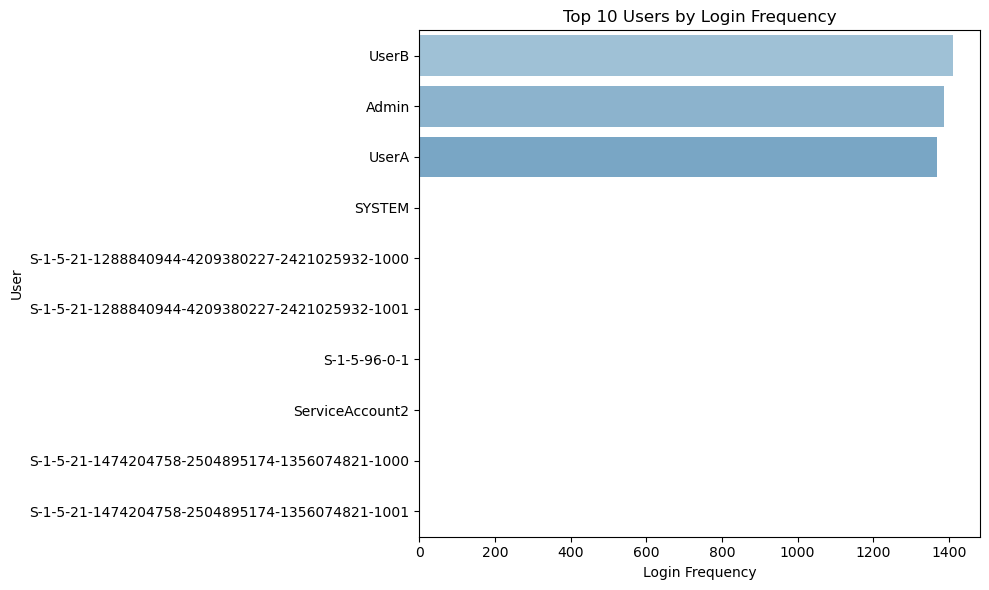

In [63]:
top_login = user_df.sort_values("login_frequency", ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(data=top_login, x="login_frequency", y="Security Identifier", palette="Blues_d")
plt.title("Top 10 Users by Login Frequency")
plt.xlabel("Login Frequency")
plt.ylabel("User")
plt.tight_layout()
plt.show()


Top 10 users by failed Logins

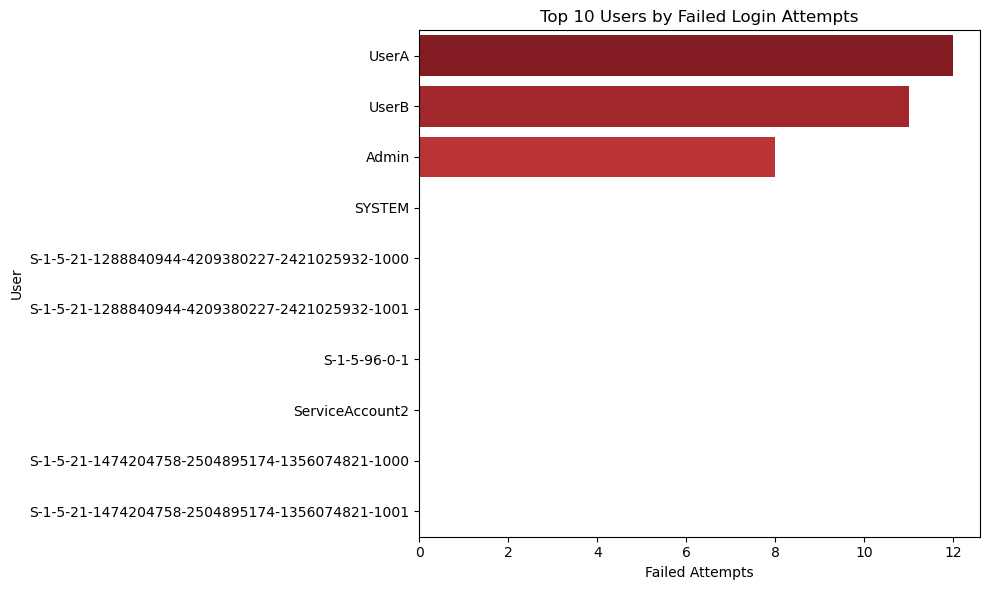

In [65]:
top_failed = user_df.sort_values("failed_login_attempts", ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(data=top_failed, x="failed_login_attempts", y="Security Identifier", palette="Reds_r")
plt.title("Top 10 Users by Failed Login Attempts")
plt.xlabel("Failed Attempts")
plt.ylabel("User")
plt.tight_layout()
plt.show()
